## Task-05

Analyze traffic accident data to identify patterns related to road conditions, weather, and time of day. Visualize accident hotspots and contributing factors.

Dataset: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents

In [2]:
import pandas as pd

accidents_df = pd.read_csv('US_Accidents_March23.csv', nrows=1000000)  # Loading only the first 1,000,000 rows because the dataset is too big for a colab session.

# Display the first few rows of the DataFrame
print("First 5 rows of the US Accidents DataFrame:")
display(accidents_df.head())

First 5 rows of the US Accidents DataFrame:


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [3]:
# Display general information about the DataFrame
print("DataFrame Info:")
display(accidents_df.info())

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     1000000 non-null  str    
 1   Source                 1000000 non-null  str    
 2   Severity               1000000 non-null  int64  
 3   Start_Time             1000000 non-null  str    
 4   End_Time               1000000 non-null  str    
 5   Start_Lat              1000000 non-null  float64
 6   Start_Lng              1000000 non-null  float64
 7   End_Lat                0 non-null        float64
 8   End_Lng                0 non-null        float64
 9   Distance(mi)           1000000 non-null  float64
 10  Description            999999 non-null   str    
 11  Street                 998288 non-null   str    
 12  City                   999972 non-null   str    
 13  County                 1000000 non-null  str    
 14  State         

None

In [4]:
# Display descriptive statistics for numerical columns
print("Descriptive statistics for numerical columns:")
display(accidents_df.describe())

Descriptive statistics for numerical columns:


,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,1000000.000000,1000000.000000,1000000.000000,0.0,0.0,1000000.000000,984702.000000,539411.000000,983447.000000,987624.000000,981069.000000,899602.000000,524684.000000
mean,2.320200,36.059323,-94.753951,NaN,NaN,0.167486,64.619012,59.439159,66.026522,29.693616,9.173668,7.767917,0.013259
std,0.548478,4.906870,17.391816,NaN,NaN,1.427785,17.450734,21.930704,21.890455,0.792132,2.259461,5.408117,0.203154
min,1.000000,24.554800,-124.497414,NaN,NaN,0.000000,-77.800000,-50.000000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,32.925510,-117.370224,NaN,NaN,0.000000,54.000000,43.000000,50.000000,29.560000,10.000000,4.600000,0.000000
50%,2.000000,35.258339,-87.957626,NaN,NaN,0.000000,66.900000,64.000000,68.000000,29.910000,10.000000,7.000000,0.000000
75%,3.000000,40.113201,-80.919167,NaN,NaN,0.010000,77.000000,76.000000,84.000000,30.050000,10.000000,10.400000,0.000000
max,4.000000,48.998085,-68.160789,NaN,NaN,336.570007,196.000000,196.000000,100.000000,58.100000,111.000000,822.800000,36.470000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

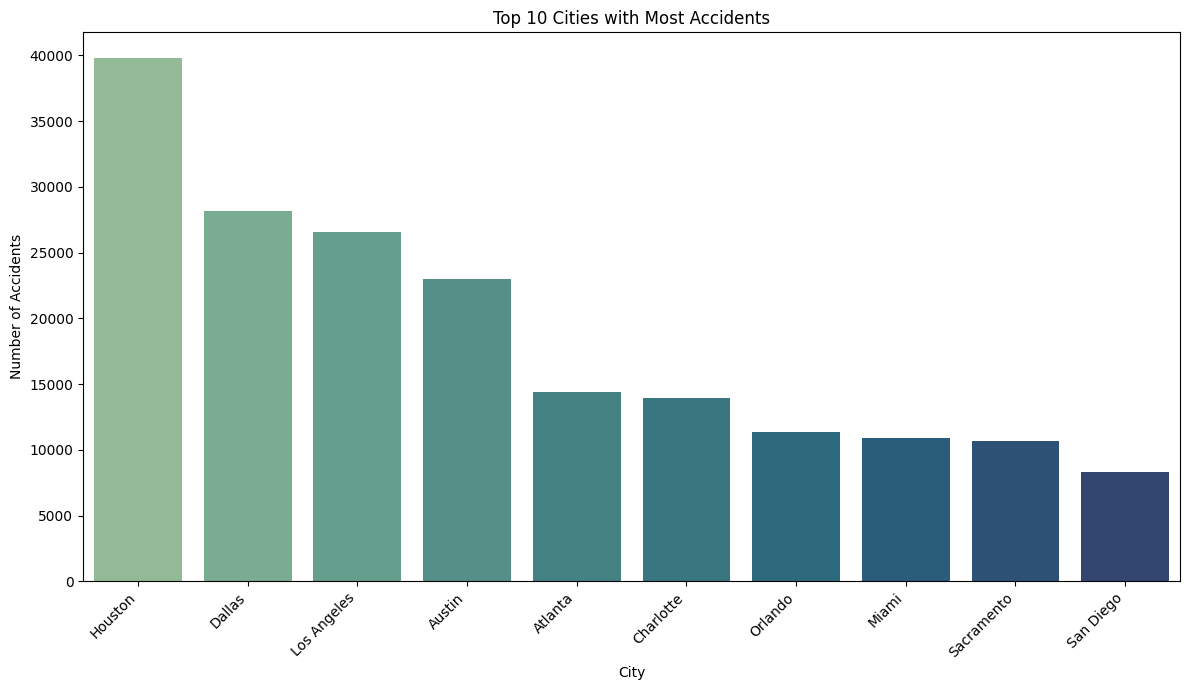

In [6]:
# Calculate top 10 cities by accident count
top_cities = accidents_df['City'].value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_cities.index, y=top_cities.values, palette='crest', hue=top_cities.index, legend=False)
plt.title('Top 10 Cities with Most Accidents')
plt.xlabel('City')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

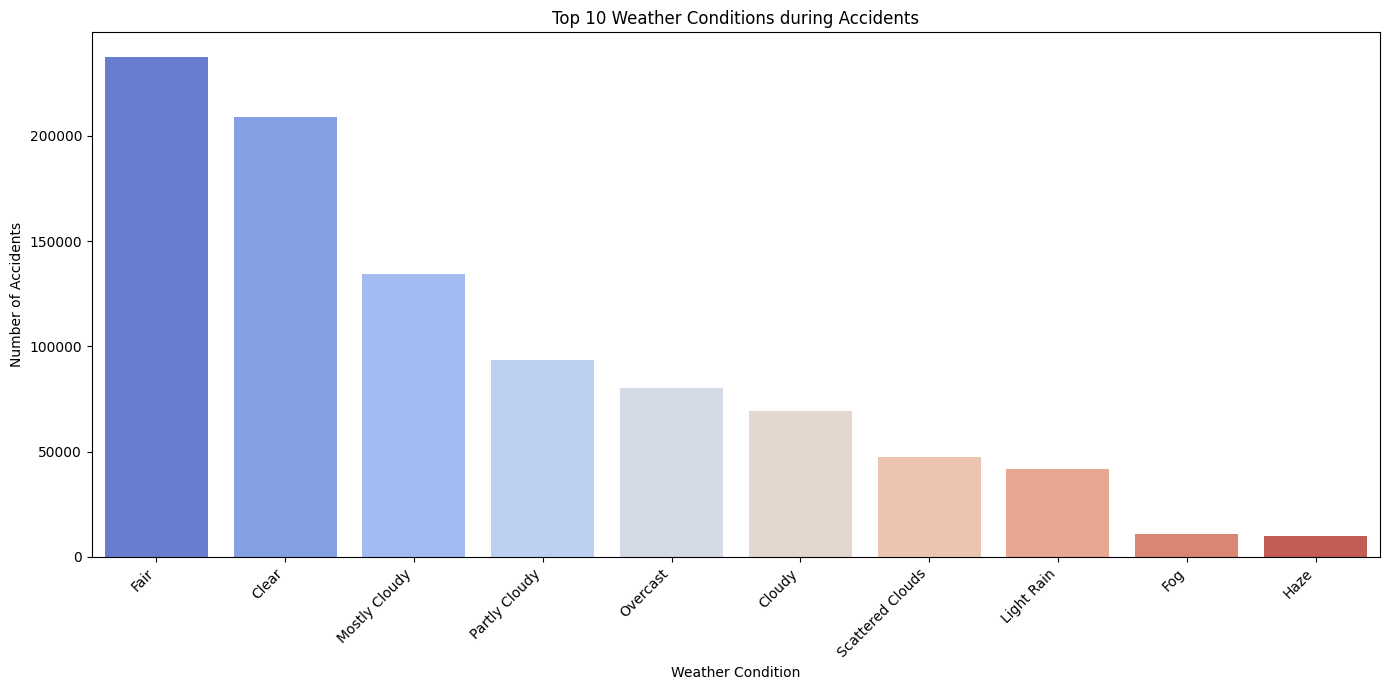

In [9]:
# Get top 10 weather conditions
top_weather_conditions = accidents_df['Weather_Condition'].value_counts().nlargest(10)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_weather_conditions.index, y=top_weather_conditions.values, palette='coolwarm', hue=top_weather_conditions.index, legend=False)
plt.title('Top 10 Weather Conditions during Accidents')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

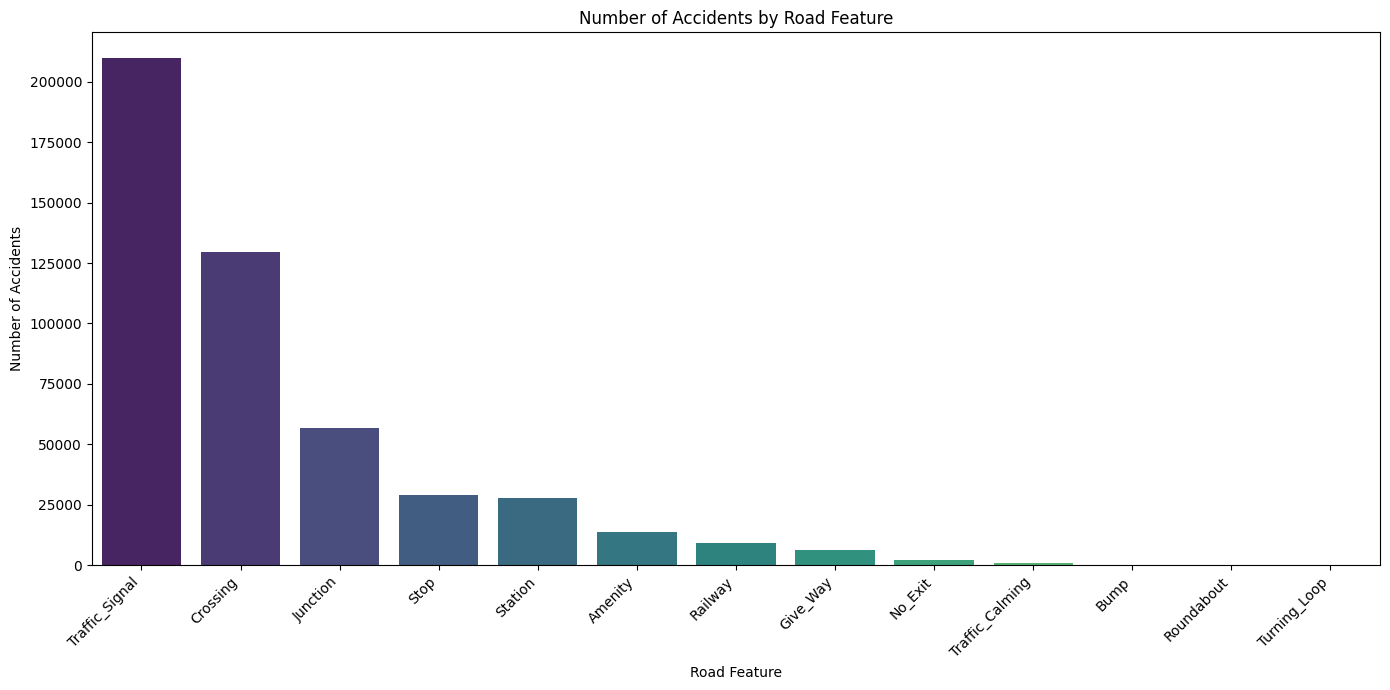

In [10]:
# Select relevant boolean road feature columns
road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
                 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
                 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

# Create a DataFrame for counts of accidents at each feature
feature_counts = accidents_df[road_features].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x=feature_counts.index, y=feature_counts.values, palette='viridis', hue=feature_counts.index, legend=False)
plt.title('Number of Accidents by Road Feature')
plt.xlabel('Road Feature')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

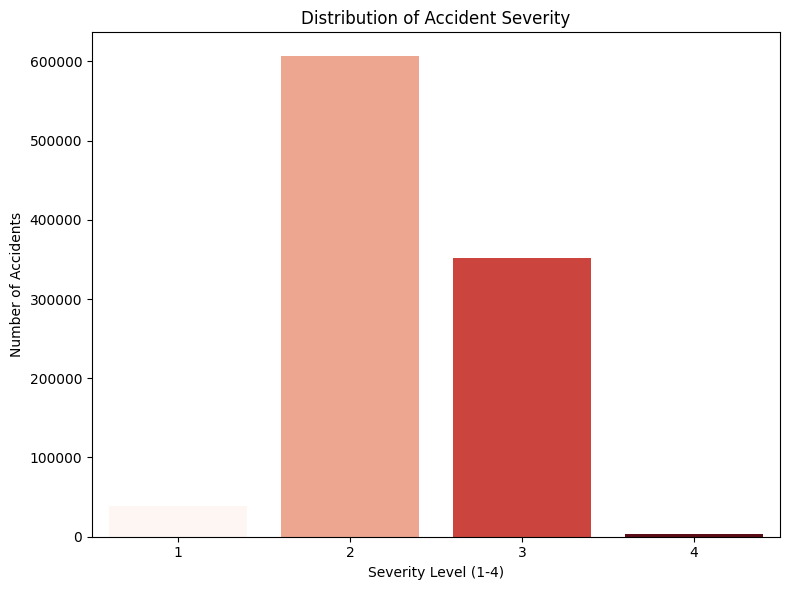

In [11]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Severity', data=accidents_df, palette='Reds', hue='Severity', legend=False)
plt.title('Distribution of Accident Severity')
plt.xlabel('Severity Level (1-4)')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.show()